# Clinical Efficacy Pipeline: Lighthouse Sanctuary

## 1. Problem Framing

### Business problem
Lighthouse Sanctuary needs evidence-based guidance on which counseling interventions are associated with sustained resident improvement, while also identifying residents at risk of stalled progress early enough for intervention.

### Dual objective (Chapter 1 framing)
- **Explanatory objective:** Estimate relationships between interventions and sustained health improvement while controlling for baseline condition and confounding context.
- **Predictive objective:** Forecast which resident-month cases are likely to stall so the program team can triage support.

In IS 455 terms (Chapter 1), this translates domain context into two distinct technical tasks: an interpretable model for explanation and a performance-oriented model for operational prediction.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid')

# Resolve data path robustly whether notebook runs from its own folder or repo root
candidate_dirs = [
    Path('../../data/raw'),
    Path('data/raw'),
]
DATA_DIR = next((p for p in candidate_dirs if p.exists()), Path('../../data/raw'))

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

try:
    import statsmodels.api as sm
    STATSMODELS_AVAILABLE = True
except Exception:
    STATSMODELS_AVAILABLE = False

print(f'Data dir exists: {DATA_DIR.exists()}')
print(f'Statsmodels available: {STATSMODELS_AVAILABLE}')

Data dir exists: True
Statsmodels available: True


## 2. Data Acquisition, Preparation & Exploration

This section builds a reproducible longitudinal dataset. The central engineering task is the **Resident-Month Spine**, which aligns daily counseling sessions with monthly outcomes. We then derive a 6-month sustained-impact target and confounders before any modeling.

We also implement Chapter 7 reproducibility principles by defining preprocessing with `ColumnTransformer` and `Pipeline`.

In [2]:
# Load source tables
residents = pd.read_csv(DATA_DIR / 'residents.csv')
process_recordings = pd.read_csv(DATA_DIR / 'process_recordings.csv')
health = pd.read_csv(DATA_DIR / 'health_wellbeing_records.csv')
education = pd.read_csv(DATA_DIR / 'education_records.csv')
incidents = pd.read_csv(DATA_DIR / 'incident_reports.csv')

# Parse temporal fields
residents['date_enrolled'] = pd.to_datetime(residents['date_enrolled'], errors='coerce')
residents['date_closed'] = pd.to_datetime(residents['date_closed'], errors='coerce')

process_recordings['session_date'] = pd.to_datetime(process_recordings['session_date'], errors='coerce')
health['record_date'] = pd.to_datetime(health['record_date'], errors='coerce')
education['record_date'] = pd.to_datetime(education['record_date'], errors='coerce')
incidents['incident_date'] = pd.to_datetime(incidents['incident_date'], errors='coerce')

# Monthly keys
health['month'] = health['record_date'].dt.to_period('M').dt.to_timestamp()
education['month'] = education['record_date'].dt.to_period('M').dt.to_timestamp()
process_recordings['month'] = process_recordings['session_date'].dt.to_period('M').dt.to_timestamp()
incidents['month'] = incidents['incident_date'].dt.to_period('M').dt.to_timestamp()

print('Loaded tables:')
print({
    'residents': residents.shape,
    'process_recordings': process_recordings.shape,
    'health': health.shape,
    'education': education.shape,
    'incidents': incidents.shape,
})

Loaded tables:
{'residents': (60, 49), 'process_recordings': (2819, 16), 'health': (534, 15), 'education': (534, 11), 'incidents': (100, 13)}


In [3]:
# Build Resident-Month Spine based on health observation window per resident
resident_month_ranges = (
    health.groupby('resident_id')['month']
    .agg(month_min='min', month_max='max')
    .dropna()
    .reset_index()
)

spine_rows = []
for _, row in resident_month_ranges.iterrows():
    months = pd.date_range(start=row['month_min'], end=row['month_max'], freq='MS')
    for m in months:
        spine_rows.append((row['resident_id'], m))

spine = pd.DataFrame(spine_rows, columns=['resident_id', 'month'])

# Health at T and T+6 to create sustained impact target
health_monthly = health[['resident_id', 'month', 'general_health_score']].copy()
health_t = health_monthly.rename(columns={'general_health_score': 'general_health_score_t'})
health_tp6 = health_monthly.copy()
health_tp6['month'] = health_tp6['month'] - pd.DateOffset(months=6)
health_tp6 = health_tp6.rename(columns={'general_health_score': 'general_health_score_t_plus_6'})

spine = spine.merge(health_t, on=['resident_id', 'month'], how='left')
spine = spine.merge(health_tp6, on=['resident_id', 'month'], how='left')
spine['health_score_delta_6m'] = spine['general_health_score_t_plus_6'] - spine['general_health_score_t']

# Education baseline at T for richer context
edu_monthly = (
    education.groupby(['resident_id', 'month'], as_index=False)
    .agg(
        attendance_rate_t=('attendance_rate', 'mean'),
        progress_percent_t=('progress_percent', 'mean')
    )
)
spine = spine.merge(edu_monthly, on=['resident_id', 'month'], how='left')

print('Spine shape:', spine.shape)
print('Target non-null rows:', spine['health_score_delta_6m'].notna().sum())
spine.head()

Spine shape: (534, 7)
Target non-null rows: 174


,resident_id,month,general_health_score_t,general_health_score_t_plus_6,health_score_delta_6m,attendance_rate_t,progress_percent_t
0,1,2023-10-01,3.09,NaN,NaN,0.966,37.7
1,1,2023-11-01,3.05,NaN,NaN,0.693,33.0
2,1,2023-12-01,3.05,NaN,NaN,0.744,54.0
3,1,2024-01-01,3.08,NaN,NaN,0.681,51.2
4,1,2024-02-01,3.13,NaN,NaN,0.721,44.2


In [4]:
# Parse and aggregate interventions into monthly one-hot count features
pr = process_recordings[['resident_id', 'month', 'interventions_applied']].copy()
pr = pr.dropna(subset=['resident_id', 'month'])
pr['interventions_applied'] = pr['interventions_applied'].fillna('')

pr['intervention_list'] = (
    pr['interventions_applied']
    .str.split(',')
    .apply(lambda vals: [v.strip().lower().replace(' ', '_') for v in vals if str(v).strip()])
)

pr_exploded = pr.explode('intervention_list')
pr_exploded = pr_exploded[pr_exploded['intervention_list'].notna() & (pr_exploded['intervention_list'] != '')]

intervention_counts = (
    pr_exploded
    .groupby(['resident_id', 'month', 'intervention_list'])
    .size()
    .unstack(fill_value=0)
)

intervention_counts.columns = [f'intervention_{c}_count' for c in intervention_counts.columns]
intervention_counts = intervention_counts.reset_index()

# Aggregate incident confounders
incidents['severity_clean'] = incidents['severity'].astype(str).str.strip().str.lower()
incident_monthly = (
    incidents.groupby(['resident_id', 'month'], as_index=False)
    .agg(
        monthly_total_incidents=('incident_id', 'count'),
        monthly_high_severity_incidents=('severity_clean', lambda s: (s == 'high').sum())
    )
)

# Static controls from resident profile
resident_controls = residents[['resident_id', 'safehouse_id', 'sex', 'initial_risk_level', 'current_risk_level', 'age_upon_admission']].copy()

# Merge all feature components
model_df = (
    spine
    .merge(intervention_counts, on=['resident_id', 'month'], how='left')
    .merge(incident_monthly, on=['resident_id', 'month'], how='left')
    .merge(resident_controls, on='resident_id', how='left')
)

intervention_cols = [c for c in model_df.columns if c.startswith('intervention_') and c.endswith('_count')]
model_df[intervention_cols] = model_df[intervention_cols].fillna(0)
model_df[['monthly_total_incidents', 'monthly_high_severity_incidents']] = model_df[['monthly_total_incidents', 'monthly_high_severity_incidents']].fillna(0)

# Binary stall outcome for classification framing in evaluation
model_df['stalled_6m'] = (model_df['health_score_delta_6m'] <= 0).astype('Int64')

print('Modeling table shape:', model_df.shape)
print('Intervention feature count:', len(intervention_cols))
model_df.head()

Modeling table shape: (534, 19)
Intervention feature count: 4


,resident_id,month,general_health_score_t,general_health_score_t_plus_6,health_score_delta_6m,attendance_rate_t,progress_percent_t,intervention_caring_count,intervention_healing_count,intervention_legal_services_count,intervention_teaching_count,monthly_total_incidents,monthly_high_severity_incidents,safehouse_id,sex,initial_risk_level,current_risk_level,age_upon_admission,stalled_6m
0,1,2023-10-01,3.09,NaN,NaN,0.966,37.7,0.0,0.0,0.0,0.0,0.0,0.0,4,F,Critical,High,15 Years 9 months,0
1,1,2023-11-01,3.05,NaN,NaN,0.693,33.0,1.0,1.0,2.0,0.0,0.0,0.0,4,F,Critical,High,15 Years 9 months,0
2,1,2023-12-01,3.05,NaN,NaN,0.744,54.0,1.0,3.0,2.0,3.0,0.0,0.0,4,F,Critical,High,15 Years 9 months,0
3,1,2024-01-01,3.08,NaN,NaN,0.681,51.2,0.0,2.0,1.0,0.0,0.0,0.0,4,F,Critical,High,15 Years 9 months,0
4,1,2024-02-01,3.13,NaN,NaN,0.721,44.2,2.0,1.0,2.0,0.0,1.0,0.0,4,F,Critical,High,15 Years 9 months,0


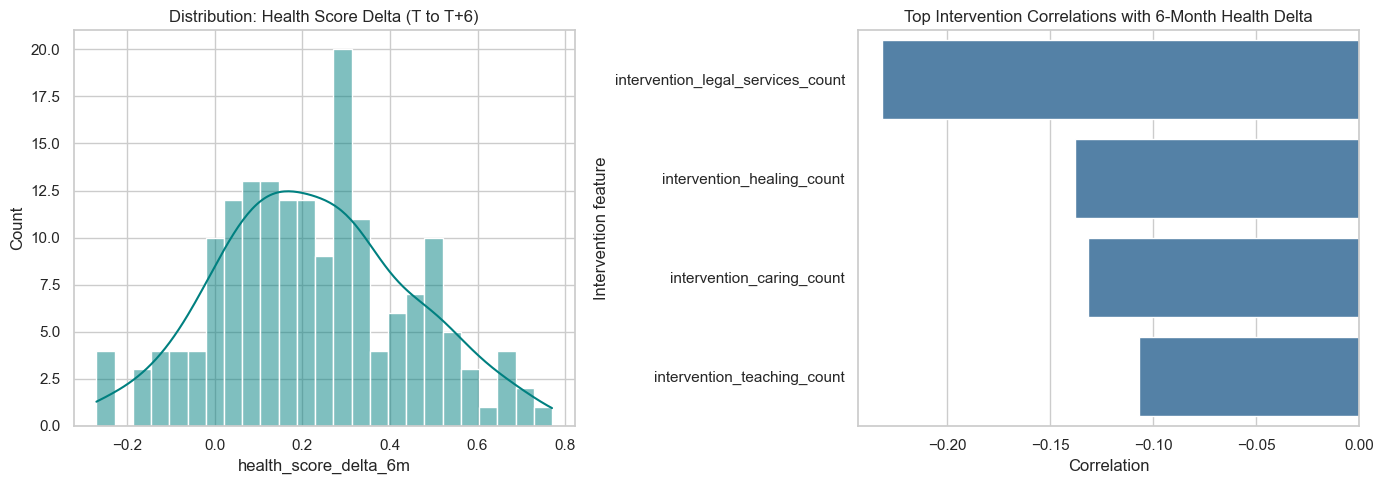

Prepared X shape: (174, 13)
Numeric columns: 10 | Categorical columns: 3


In [5]:
# Exploratory analysis: target distribution and intervention correlations
eda_df = model_df.dropna(subset=['health_score_delta_6m']).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(eda_df['health_score_delta_6m'], bins=25, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution: Health Score Delta (T to T+6)')
axes[0].set_xlabel('health_score_delta_6m')

corr_source_cols = intervention_cols + ['health_score_delta_6m']
corr_series = eda_df[corr_source_cols].corr(numeric_only=True)['health_score_delta_6m'].drop('health_score_delta_6m')
top_corr = corr_series.reindex(corr_series.abs().sort_values(ascending=False).head(10).index)

sns.barplot(x=top_corr.values, y=top_corr.index, ax=axes[1], color='steelblue')
axes[1].set_title('Top Intervention Correlations with 6-Month Health Delta')
axes[1].set_xlabel('Correlation')
axes[1].set_ylabel('Intervention feature')

plt.tight_layout()
plt.show()

# Reproducible preprocessing via Chapter 7 pipeline tools
feature_cols = [
    'general_health_score_t',
    'attendance_rate_t',
    'progress_percent_t',
    'monthly_total_incidents',
    'monthly_high_severity_incidents',
    'safehouse_id',
    'sex',
    'initial_risk_level',
    'current_risk_level',
    *intervention_cols,
]

model_ready = model_df.dropna(subset=['health_score_delta_6m']).copy()
X = model_ready[feature_cols].copy()
y = model_ready['health_score_delta_6m'].copy()
y_cls = (model_ready['health_score_delta_6m'] <= 0).astype(int)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ]
)

print('Prepared X shape:', X.shape)
print('Numeric columns:', len(numeric_cols), '| Categorical columns:', len(categorical_cols))

## 3. Modeling & Feature Selection

We now separate modeling goals explicitly:

- **Explanatory model (interpretability-first):** OLS to estimate directional and statistical relationships between intervention counts and 6-month health improvement.
- **Predictive model (accuracy-first):** Random Forest model optimized for out-of-sample performance to identify residents at risk of stalling.

Feature selection reflects domain logic: baseline health and education status, intervention dosage, and monthly incident burden as a confounder for destabilizing events.

In [6]:
# Temporal split (preferred) by month cutoff
split_cutoff = model_ready['month'].quantile(0.80)
train_mask = model_ready['month'] <= split_cutoff
test_mask = model_ready['month'] > split_cutoff

if test_mask.sum() < 30 or train_mask.sum() < 60:
    # Fallback to standard split if temporal holdout is too small
    X_train, X_test, y_train, y_test, y_cls_train, y_cls_test = train_test_split(
        X, y, y_cls, test_size=0.2, random_state=42
    )
    split_strategy = 'random_train_test_split'
else:
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    y_cls_train, y_cls_test = y_cls[train_mask], y_cls[test_mask]
    split_strategy = 'temporal_holdout'

print('Split strategy:', split_strategy)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])

# Explanatory model: OLS with explicit numeric design matrix
X_train_ols = pd.get_dummies(X_train, drop_first=True)
X_test_ols = pd.get_dummies(X_test, drop_first=True)
X_test_ols = X_test_ols.reindex(columns=X_train_ols.columns, fill_value=0)

# Statsmodels requires numeric array-like inputs
X_train_ols = X_train_ols.apply(pd.to_numeric, errors='coerce').fillna(0.0).astype(float)
X_test_ols = X_test_ols.apply(pd.to_numeric, errors='coerce').fillna(0.0).astype(float)
y_train_ols = pd.to_numeric(y_train, errors='coerce').astype(float)

ols_results = None
if STATSMODELS_AVAILABLE:
    X_train_const = sm.add_constant(X_train_ols)
    ols_model = sm.OLS(y_train_ols, X_train_const).fit()
    ols_results = ols_model
    print(ols_model.summary().tables[1])
else:
    print('statsmodels not available; OLS significance table skipped.')

# Predictive model (regression)
rf_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=400,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

rf_reg_pipeline.fit(X_train, y_train)
y_pred_reg = rf_reg_pipeline.predict(X_test)

# Optional predictive classifier for stalled risk
rf_cls_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

rf_cls_pipeline.fit(X_train, y_cls_train)
y_pred_cls = rf_cls_pipeline.predict(X_test)

print('Model training complete.')

Split strategy: random_train_test_split
Train size: 139 | Test size: 35
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                 0.0424      0.340      0.125      0.901      -0.630       0.715
general_health_score_t                0.1641      0.107      1.528      0.129      -0.049       0.377
attendance_rate_t                    -0.3634      0.178     -2.036      0.044      -0.717      -0.010
progress_percent_t                    0.0006      0.001      0.594      0.554      -0.001       0.003
monthly_total_incidents               0.0802      0.077      1.044      0.299      -0.072       0.232
monthly_high_severity_incidents      -0.0187      0.129     -0.145      0.885      -0.274       0.237
safehouse_id                         -0.0180      0.008     -2.295      0.023      -0.033      -0.002
interventi

## 4. Evaluation & Interpretation

Evaluation is aligned to operational decisions:
- For continuous outcome estimation, we report **MAE** and **RMSE**.
- For risk triage, we use **Precision** and **Recall** on a binary stalled-vs-improved framing.

From a program perspective:
- **False positive** (flagging a stable resident) consumes scarce staff attention.
- **False negative** (missing a genuinely stalled resident) risks prolonged harm and delayed intervention, which is usually the higher-cost error.

MAE:  0.1829
RMSE: 0.2166
Precision (stalled class): 0.3333
Recall (stalled class):    0.1111

Classification report:
              precision    recall  f1-score   support

           0     0.7500    0.9231    0.8276        26
           1     0.3333    0.1111    0.1667         9

    accuracy                         0.7143        35
   macro avg     0.5417    0.5171    0.4971        35
weighted avg     0.6429    0.7143    0.6576        35



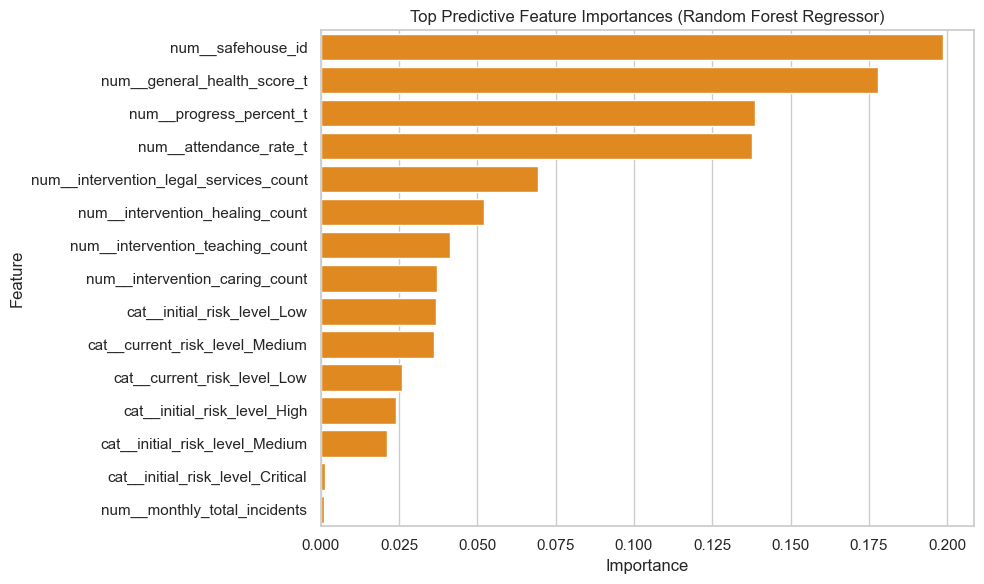

num__safehouse_id                         0.198632
num__general_health_score_t               0.177890
num__progress_percent_t                   0.138534
num__attendance_rate_t                    0.137838
num__intervention_legal_services_count    0.069516
num__intervention_healing_count           0.052072
num__intervention_teaching_count          0.041399
num__intervention_caring_count            0.037036
cat__initial_risk_level_Low               0.036765
cat__current_risk_level_Medium            0.036128
dtype: float64

In [7]:
# Regression metrics
mae = mean_absolute_error(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)

print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')

# Classification metrics for stall detection
precision = precision_score(y_cls_test, y_pred_cls, zero_division=0)
recall = recall_score(y_cls_test, y_pred_cls, zero_division=0)

print(f'Precision (stalled class): {precision:.4f}')
print(f'Recall (stalled class):    {recall:.4f}')
print('\nClassification report:')
print(classification_report(y_cls_test, y_pred_cls, digits=4, zero_division=0))

# Predictive feature importance (regression model)
rf_model = rf_reg_pipeline.named_steps['model']
feat_names = rf_reg_pipeline.named_steps['preprocessor'].get_feature_names_out()
feat_importance = pd.Series(rf_model.feature_importances_, index=feat_names).sort_values(ascending=False)

top_importance = feat_importance.head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_importance.values, y=top_importance.index, color='darkorange')
plt.title('Top Predictive Feature Importances (Random Forest Regressor)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

top_importance.head(10)

## 5. Causal and Relationship Analysis

### Interpreting explanatory coefficients
If `statsmodels` is available, the OLS table reports coefficients, p-values, and confidence intervals for intervention features and controls.

- Positive and statistically significant intervention coefficients indicate an **association** with higher 6-month health improvement, holding included controls constant.
- High-severity incident burden is expected to be negatively associated with improvement, acting as a contextual destabilizer.

### Causal caution (critical)
This is observational administrative data, not a randomized experiment. Therefore:
- We should avoid strong causal claims without stronger identification strategy.
- Omitted variables (for example trauma severity not fully captured, counselor quality, family dynamics) can bias coefficient estimates.
- Time-varying confounding may remain even with monthly controls.

### Explanatory vs predictive contrast
The Random Forest may prioritize non-linear or interaction-heavy predictors that differ from OLS-significant terms. Divergence between these views is expected: one optimizes interpretability and directional inference, the other pure prediction error minimization.

In [8]:
# Extract significant intervention terms from OLS (if available)
if ols_results is not None:
    coef_table = pd.DataFrame({
        'coef': ols_results.params,
        'p_value': ols_results.pvalues,
        'ci_low': ols_results.conf_int()[0],
        'ci_high': ols_results.conf_int()[1],
    })
    intervention_mask = coef_table.index.str.contains('intervention_', regex=False)
    significant_interventions = (
        coef_table[intervention_mask]
        .sort_values('p_value')
        .query('p_value < 0.05')
    )

    print('Significant intervention terms (p < 0.05):')
    print(significant_interventions.head(20))
else:
    print('Significance extraction skipped because statsmodels is unavailable.')

print('Top predictive features from black-box model:')
print(top_importance.head(10))

Significant intervention terms (p < 0.05):
Empty DataFrame
Columns: [coef, p_value, ci_low, ci_high]
Index: []
Top predictive features from black-box model:
num__safehouse_id                         0.198632
num__general_health_score_t               0.177890
num__progress_percent_t                   0.138534
num__attendance_rate_t                    0.137838
num__intervention_legal_services_count    0.069516
num__intervention_healing_count           0.052072
num__intervention_teaching_count          0.041399
num__intervention_caring_count            0.037036
cat__initial_risk_level_Low               0.036765
cat__current_risk_level_Medium            0.036128
dtype: float64


## 6. Deployment Notes

### Proposed production integration
- A nightly batch pipeline extracts the latest resident-month features from the transactional database.
- The predictive model scores each resident-month for stall risk and writes results to a `resident_risk_scores` table.
- The web app reads this table to power a **Risk Dashboard** for the Program Director (sortable by risk, recent intervention exposure, and unresolved incidents).
- Alert thresholds can trigger workflow tickets for social workers.

### Governance and continuous improvement
- The explanatory model is reviewed monthly by clinical leadership to update intervention guidelines.
- Predictive performance is monitored for drift (MAE/RMSE and recall for stalled cases).
- Retraining cadence should start monthly, then shift to event-based retraining if drift accelerates.

In [ ]:
## Export to Supabase — resident_ml_scores (stall_risk_band)
# Run this cell after the notebook completes to push stall risk scores to Supabase.
# Requires: pip install supabase
# Set SUPABASE_URL and SUPABASE_SERVICE_KEY as environment variables.

import os
from supabase import create_client

SUPABASE_URL = os.environ["SUPABASE_URL"]
SUPABASE_SERVICE_KEY = os.environ["SUPABASE_SERVICE_KEY"]
client = create_client(SUPABASE_URL, SUPABASE_SERVICE_KEY)

# Score ALL resident-month rows (model_df = full 534-row frame, not just model_ready)
# rf_cls_pipeline includes a SimpleImputer so NaN values are safe to pass in.
all_features = model_df[feature_cols].copy()
stall_proba = rf_cls_pipeline.predict_proba(all_features)[:, 1]  # P(stalled)

scoring_frame = model_df[['resident_id', 'month']].copy()
scoring_frame['stall_prob'] = stall_proba

# Take the most recent month per resident as the score to surface in the UI
latest = (
    scoring_frame
    .sort_values('month')
    .groupby('resident_id')
    .last()
    .reset_index()
)

def assign_stall_band(prob):
    if prob >= 0.60:
        return 'High'
    elif prob >= 0.35:
        return 'Medium'
    else:
        return 'Low'

latest['stall_risk_band'] = latest['stall_prob'].apply(assign_stall_band)
latest['model_version'] = '1.0'

rows = latest[['resident_id', 'stall_risk_band', 'model_version']].to_dict(orient='records')

result = client.table('resident_ml_scores').upsert(rows, on_conflict='resident_id').execute()
print(f"Upserted {len(rows)} rows to resident_ml_scores (stall_risk_band).")
print("Band distribution:")
print(latest['stall_risk_band'].value_counts().to_string())
print("Sample rows:", rows[:3])
